In [1]:
using Pkg
using CSV
using DataFrames
using Polynomials
using CairoMakie
using Statistics

In [2]:
include("D:/01 Projekt/03 Programm/Rini aktuell/Rini/src/TIRA.jl")

Main.TIRA

## Plots

## Proben Geometrie

In [3]:
## Geometrie
w=10*1e-3 # Width
t=15.5*1e-6 # thickness W3 from the 2nd batch
l=60*1e-3 # length between clamps
As=w*t    # stress section

1.55e-7

## Raum Temperature

In [4]:

BaseName="AP5ZMEF01-2/260126-"
name="260126-"
file_path = "$(BaseName)$(2).csv"

"AP5ZMEF01-2/260126-2.csv"

In [5]:
df_260126=[]

Any[]

In [7]:
DataProperties=[]

Any[]

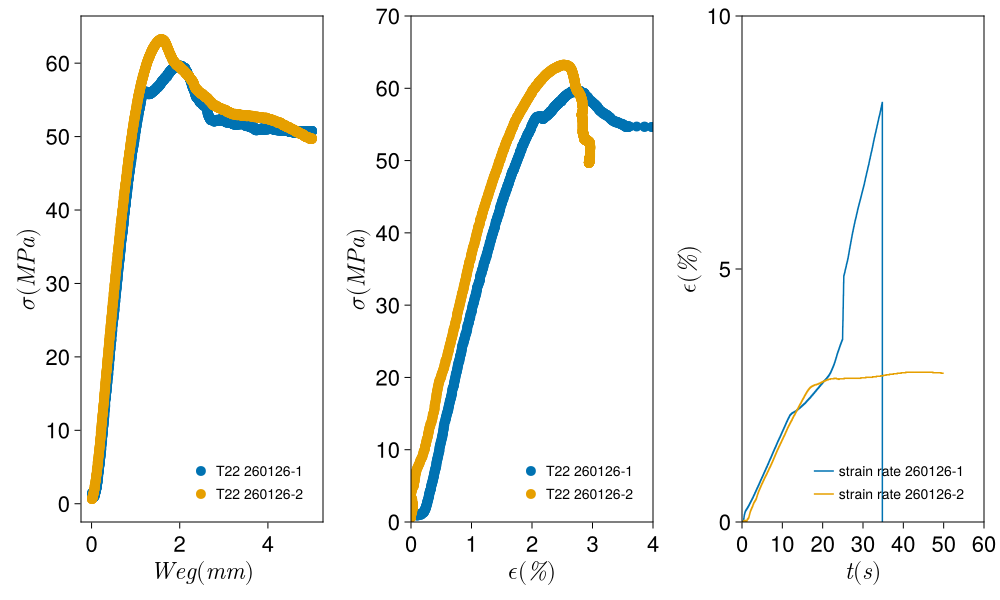

In [13]:

#### Raum T


# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"Weg (mm)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax3_Raum = Axis(figRaum[1,3],
    xlabel = L"t (s)",
    ylabel = L"ϵ (%)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


## Filter Data


for i in [1 2]
        
        df=TIRA.computeStressStrain(BaseName,name,i,22,As)
        df=TIRA.filter_range(df,"Weg",0,5)

        Makie.scatter!(ax1_Raum ,df[!,:Weg],df[!,:Stress];
        markersize=14, 
        label = "T22 $(name)$(i)")


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T22 $(name)$(i)")
        limits!(ax2_Raum, 0, 4, 0, 70)

    
        Makie.lines!(ax3_Raum ,df[!,:Zeit],df[!,:Strain];
        
        label = "strain rate $(name)$(i)")
        limits!(ax3_Raum, 0, 60, 0, 10)
        #limits!(ax3_Raum, 0.1, 1,0,30)
        
end

df_DataProperties=DataFrame(DataProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax3_Raum, labelsize=font-10, framevisible=false,position = :rb)
figRaum

In [15]:
ϵ_LinearRange=[0.1 1]
ϵ_range=[0 4]
t_range=[0 100] #in order to avoid wrong measurements from the camera
σ_range=[0 80]
T=22

22

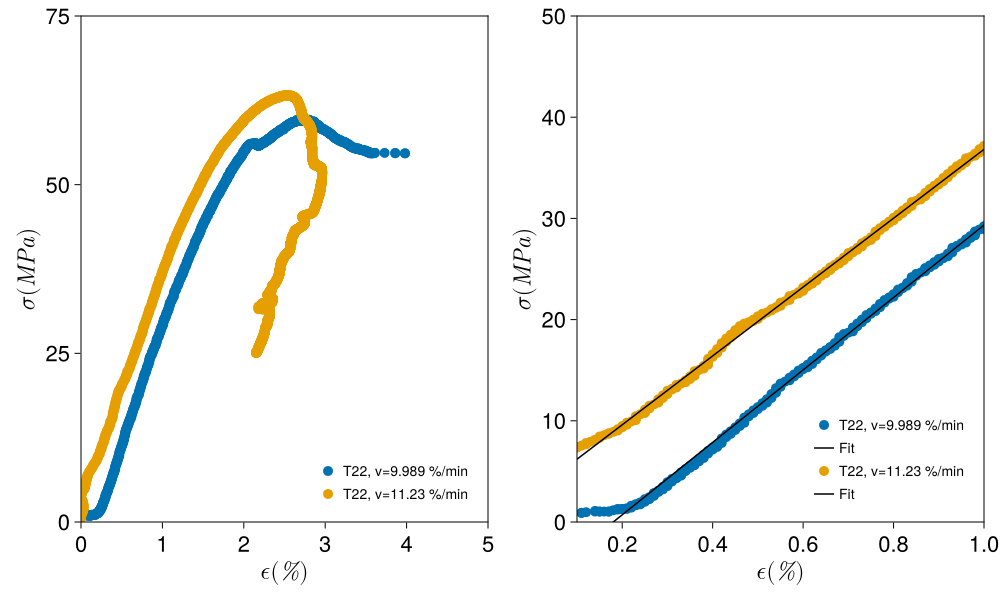

In [16]:
#### Raum T
# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)



DataProperties=[]

for i in [1 2]
        
        df=TIRA.computeStressStrain(BaseName,name,i,T,As)
        df=TIRA.filter_range(df,"Zeit",t_range[1],t_range[2])
        df=TIRA.filter_range(df,"dL_ORG",ϵ_range[1],ϵ_range[2])

        properties, df_fit=TIRA.computeProperties(df,ϵ_LinearRange,σ_range)
        
        df_Properties=DataFrame(properties)

        Makie.scatter!(ax1_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")
        
        
        limits!(ax1_Raum, 0, 5, 0, 75)


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")

        Makie.lines!(ax2_Raum ,df_fit[!,:Strain],df_fit[!,:StressFit];
        color = :black, 
        label = "Fit")
        limits!(ax2_Raum, 0.1, 1,0,50)

        push!(DataProperties,properties)
        
end

df_DataProperties=DataFrame(DataProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)

figRaum

In [329]:
df_DataProperties

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,26.528,37.1747,260126-1,2.69,"[0.11, 1.0]",0.433918,22,3.57923,59.6774,29.2258,9.98855
2,5.59948,39.6825,260126-2,2.52,"[0.1, 1.0]",0.259061,22,3.40175,63.2903,37.1613,11.2298


## Temperatur 40

In [20]:

BaseName="AP5ZMEF01-2/260126-"
name="260126-"
file_path = "$(BaseName)$(2).csv"

"AP5ZMEF01-2/260126-2.csv"

In [21]:
df_260126=[]

Any[]

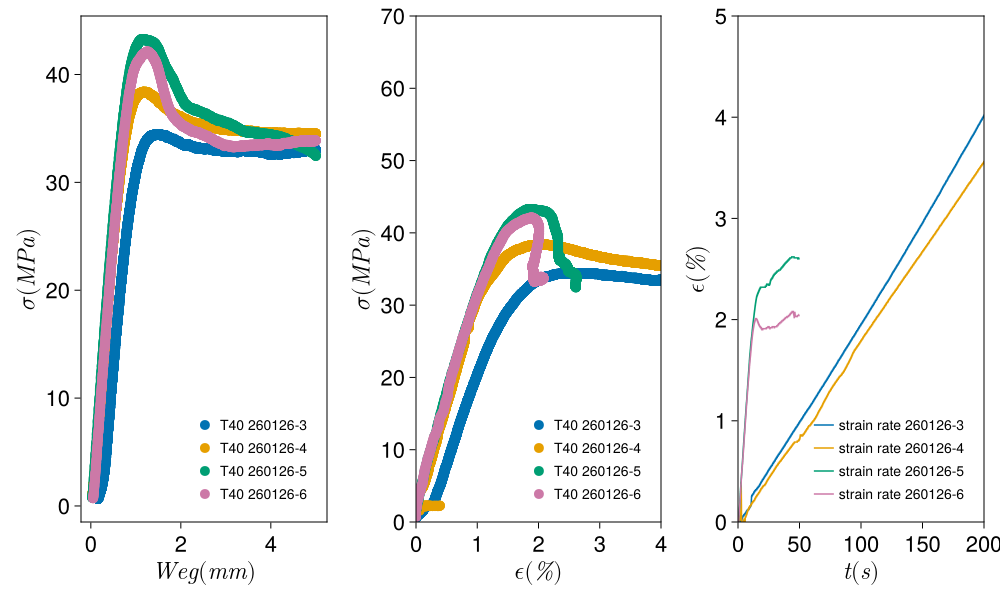

In [22]:

#### T40


# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"Weg (mm)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax3_Raum = Axis(figRaum[1,3],
    xlabel = L"t (s)",
    ylabel = L"ϵ (%)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


## Filter Data


for i in [3 4 5 6]
        
        df=TIRA.computeStressStrain(BaseName,name,i,22,As)
        df=TIRA.filter_range(df,"Weg",0,5)

        Makie.scatter!(ax1_Raum ,df[!,:Weg],df[!,:Stress];
        markersize=14, 
        label = "T40 $(name)$(i)")


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T40 $(name)$(i)")
        limits!(ax2_Raum, 0, 4, 0, 70)

    
        Makie.lines!(ax3_Raum ,df[!,:Zeit],df[!,:Strain];
        
        label = "strain rate $(name)$(i)")
        limits!(ax3_Raum, 0, 200, 0, 5)
        #limits!(ax3_Raum, 0.1, 1,0,30)
        
end

df_DataProperties=DataFrame(DataProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax3_Raum, labelsize=font-10, framevisible=false,position = :rb)
figRaum

In [23]:
ϵ_LinearRange=[0.5 1]
ϵ_range=[0 4]
t_range=[0 100] #in order to avoid wrong measurements from the camera
σ_range=[0 50]
T=40

40

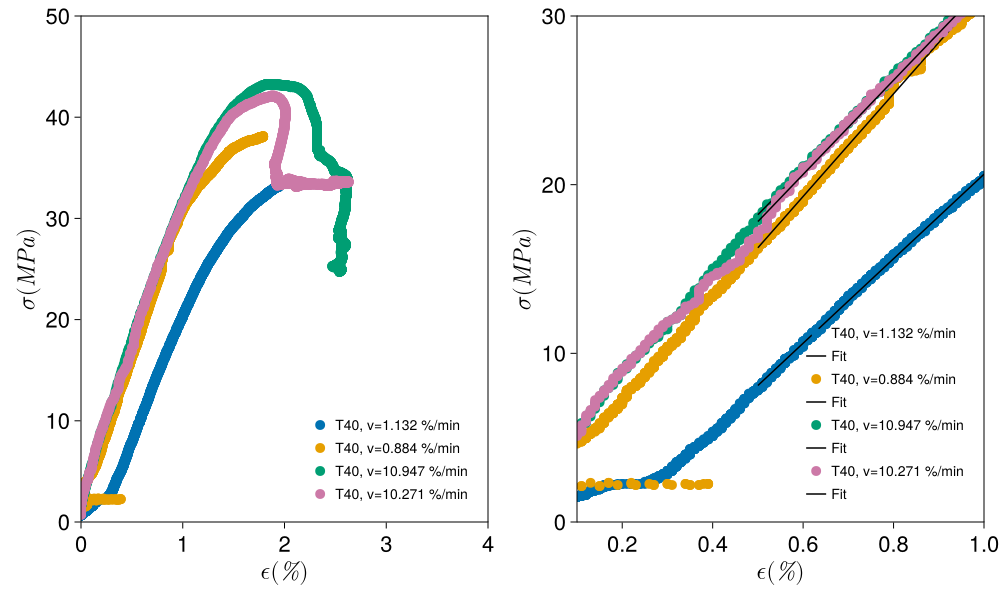

In [24]:
#### Raum T
# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)



for i in [3 4 5 6]
        
        df=TIRA.computeStressStrain(BaseName,name,i,T,As)
        df=TIRA.filter_range(df,"Zeit",t_range[1],t_range[2])
        df=TIRA.filter_range(df,"dL_ORG",ϵ_range[1],ϵ_range[2])

        properties, df_fit=TIRA.computeProperties(df,ϵ_LinearRange,σ_range)
        
        df_Properties=DataFrame(properties)

        Makie.scatter!(ax1_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")
        
        
        limits!(ax1_Raum, 0, 4, 0, 50)


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")

        Makie.lines!(ax2_Raum ,df_fit[!,:Strain],df_fit[!,:StressFit];
        color = :black, 
        label = "Fit")
        limits!(ax2_Raum, 0.1, 1,0,30)

        push!(DataProperties,properties)
        
end

df_DataProperties=DataFrame(DataProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)

figRaum

In [25]:
df_DataProperties

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,26.528,37.1747,260126-1,2.69,"[0.11, 1.0]",0.433918,22,3.57923,59.6774,29.2258,9.98855
2,5.59948,39.6825,260126-2,2.52,"[0.1, 1.0]",0.259061,22,3.40175,63.2903,37.1613,11.2298
3,4.29725,51.5464,260126-3,1.94,"[0.5, 1.0]",0.108925,40,2.5055,33.2258,20.5161,1.1322
4,2.48575,55.8659,260126-4,1.79,"[0.5, 1.0]",0.174795,40,3.04297,38.129,30.9677,0.883778
5,1.99845,54.9451,260126-5,1.82,"[0.5, 1.0]",0.27083,40,2.71908,43.2903,31.6129,10.9466
6,5.79402,53.4759,260126-6,1.87,"[0.5, 1.0]",0.582814,40,2.7931,42.129,31.5484,10.271


## Temperatur 50

In [26]:

BaseName="AP5ZMEF01-2/260126-"
name="260126-"
file_path = "$(BaseName)$(2).csv"

"AP5ZMEF01-2/260126-2.csv"

In [27]:
df_260126=[]

Any[]

In [28]:
aktuellProperties=[]

Any[]

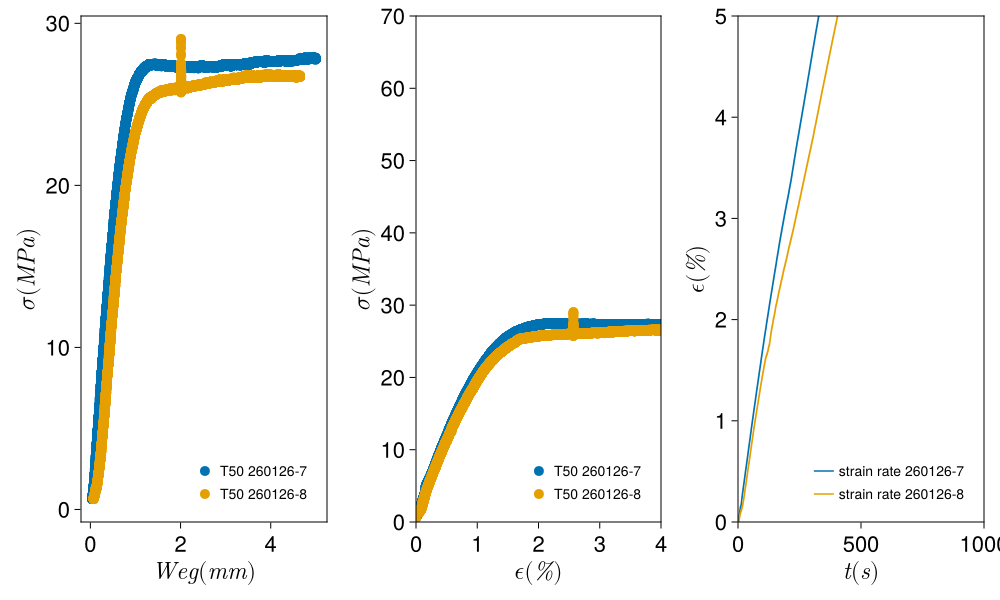

In [29]:

#### T50


# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"Weg (mm)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax3_Raum = Axis(figRaum[1,3],
    xlabel = L"t (s)",
    ylabel = L"ϵ (%)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


## Filter Data


for i in [7 8]
        
        df=TIRA.computeStressStrain(BaseName,name,i,22,As)
        df=TIRA.filter_range(df,"Weg",0,5)

        Makie.scatter!(ax1_Raum ,df[!,:Weg],df[!,:Stress];
        markersize=14, 
        label = "T50 $(name)$(i)")


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T50 $(name)$(i)")
        limits!(ax2_Raum, 0, 4, 0, 70)

    
        Makie.lines!(ax3_Raum ,df[!,:Zeit],df[!,:Strain];
        
        label = "strain rate $(name)$(i)")
        limits!(ax3_Raum, 0, 1000, 0, 5)
        #limits!(ax3_Raum, 0.1, 1,0,30)
        
end

df_DataProperties=DataFrame(DataProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax3_Raum, labelsize=font-10, framevisible=false,position = :rb)
figRaum

In [30]:
ϵ_LinearRange=[0.2 0.8]
ϵ_range=[0 4]
t_range=[0 1000] #in order to avoid wrong measurements from the camera
σ_range=[0 30]
T=50
aktuellProperties=[]

Any[]

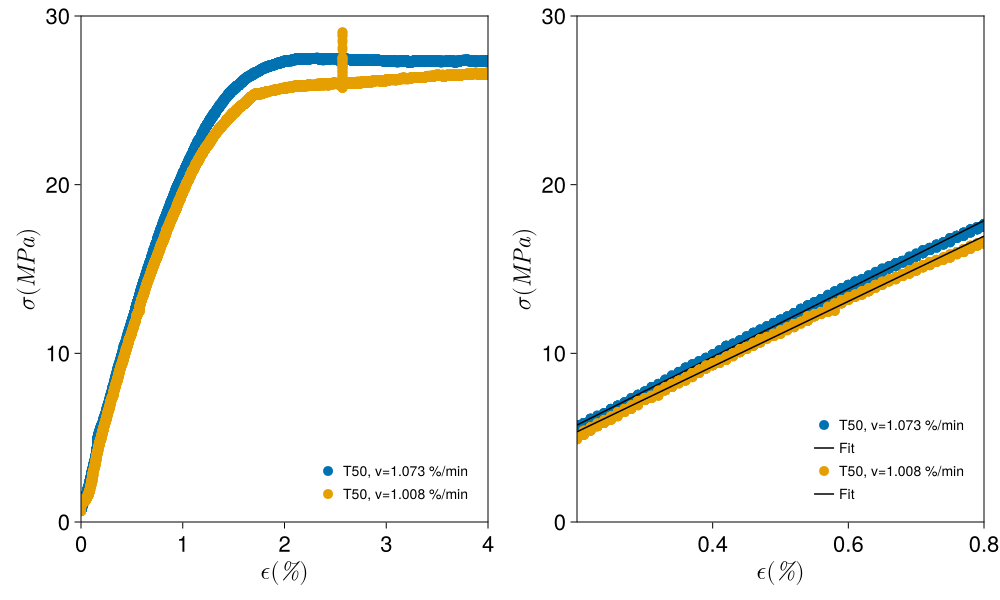

In [31]:
#### Raum T
# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)



for i in [7 8]
        
        df=TIRA.computeStressStrain(BaseName,name,i,T,As)
        df=TIRA.filter_range(df,"Zeit",t_range[1],t_range[2])
        df=TIRA.filter_range(df,"dL_ORG",ϵ_range[1],ϵ_range[2])

        properties, df_fit=TIRA.computeProperties(df,ϵ_LinearRange,σ_range)
        
        df_Properties=DataFrame(properties)

        Makie.scatter!(ax1_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")
        
        limits!(ax1_Raum, ϵ_range[1],ϵ_range[2], σ_range[1],σ_range[2])


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")

        Makie.lines!(ax2_Raum ,df_fit[!,:Strain],df_fit[!,:StressFit];
        color = :black, 
        label = "Fit")
        limits!(ax2_Raum, ϵ_LinearRange[1], ϵ_LinearRange[2], σ_range[1],σ_range[2])

        push!(aktuellProperties,properties)
        
end

df_aktuellProperties=DataFrame(aktuellProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)

figRaum

In [32]:
df_aktuellProperties

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,4.7615,34.4828,260126-7,2.32,"[0.2, 0.8]",0.0955177,50,2.01977,27.5484,17.6774,1.07343
2,9.09536,31.1284,260126-8,2.57,"[0.2, 0.8]",0.111459,50,1.9333,29.0323,16.6452,1.00756


In [33]:
push!(DataProperties,aktuellProperties[1])
push!(DataProperties,aktuellProperties[2])

8-element Vector{Any}:
 Dict{String, Any}("e_max[%]" => 26.527986989324255, "δ_F/δ_B" => 37.17472118959108, "Probe" => "260126-1", "δ_B" => 2.69, "LinearRange [%]" => [0.11, 1.0], "u_E[%] " => 0.43391837312932485, "Temperature [C]" => 22, "E[GPa] " => 3.5792303678701494, "sigmaMax" => 59.677419354838705, "sigma0_25% " => 29.225806451612904…)
 Dict{String, Any}("e_max[%]" => 5.599483284541063, "δ_F/δ_B" => 39.682539682539684, "Probe" => "260126-2", "δ_B" => 2.52, "LinearRange [%]" => [0.1, 1.0], "u_E[%] " => 0.2590609396773203, "Temperature [C]" => 22, "E[GPa] " => 3.4017543510437074, "sigmaMax" => 63.29032258064516, "sigma0_25% " => 37.16129032258065…)
 Dict{String, Any}("e_max[%]" => 4.297253383741574, "δ_F/δ_B" => 51.54639175257732, "Probe" => "260126-3", "δ_B" => 1.94, "LinearRange [%]" => [0.5, 1.0], "u_E[%] " => 0.10892456007959146, "Temperature [C]" => 40, "E[GPa] " => 2.5055038139178634, "sigmaMax" => 33.225806451612904, "sigma0_25% " => 20.516129032258064…)
 Dict{String, Any}("

In [34]:
df_DataProperties=DataFrame(DataProperties)

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,26.528,37.1747,260126-1,2.69,"[0.11, 1.0]",0.433918,22,3.57923,59.6774,29.2258,9.98855
2,5.59948,39.6825,260126-2,2.52,"[0.1, 1.0]",0.259061,22,3.40175,63.2903,37.1613,11.2298
3,4.29725,51.5464,260126-3,1.94,"[0.5, 1.0]",0.108925,40,2.5055,33.2258,20.5161,1.1322
4,2.48575,55.8659,260126-4,1.79,"[0.5, 1.0]",0.174795,40,3.04297,38.129,30.9677,0.883778
5,1.99845,54.9451,260126-5,1.82,"[0.5, 1.0]",0.27083,40,2.71908,43.2903,31.6129,10.9466
6,5.79402,53.4759,260126-6,1.87,"[0.5, 1.0]",0.582814,40,2.7931,42.129,31.5484,10.271
7,4.7615,34.4828,260126-7,2.32,"[0.2, 0.8]",0.0955177,50,2.01977,27.5484,17.6774,1.07343
8,9.09536,31.1284,260126-8,2.57,"[0.2, 0.8]",0.111459,50,1.9333,29.0323,16.6452,1.00756


## Temperatur 60

In [35]:

BaseName="AP5ZMEF01-2/260126-"
name="260126-"
file_path = "$(BaseName)$(2).csv"

"AP5ZMEF01-2/260126-2.csv"

In [36]:
aktuellProperties=[]

Any[]

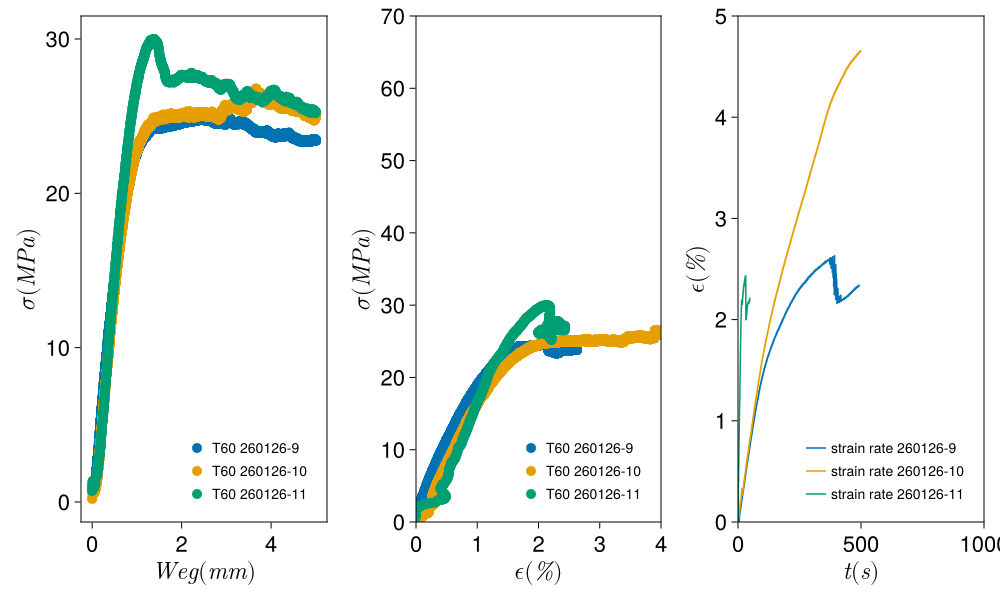

In [37]:

#### T50


# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"Weg (mm)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax3_Raum = Axis(figRaum[1,3],
    xlabel = L"t (s)",
    ylabel = L"ϵ (%)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


## Filter Data


for i in [ 9 10 11]
        
        df=TIRA.computeStressStrain(BaseName,name,i,22,As)
        df=TIRA.filter_range(df,"Weg",0,5)

        Makie.scatter!(ax1_Raum ,df[!,:Weg],df[!,:Stress];
        markersize=14, 
        label = "T60 $(name)$(i)")


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T60 $(name)$(i)")
        limits!(ax2_Raum, 0, 4, 0, 70)

    
        Makie.lines!(ax3_Raum ,df[!,:Zeit],df[!,:Strain];
        
        label = "strain rate $(name)$(i)")
        limits!(ax3_Raum, 0, 1000, 0, 5)
        #limits!(ax3_Raum, 0.1, 1,0,30)
        
end

df_DataProperties=DataFrame(DataProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax3_Raum, labelsize=font-10, framevisible=false,position = :rb)
figRaum

In [38]:
ϵ_LinearRange=[0.5 1]
ϵ_range=[0 2]
t_range=[0 1000] #in order to avoid wrong measurements from the camera
σ_range=[0 35]
T=60
aktuellProperties=[]

Any[]

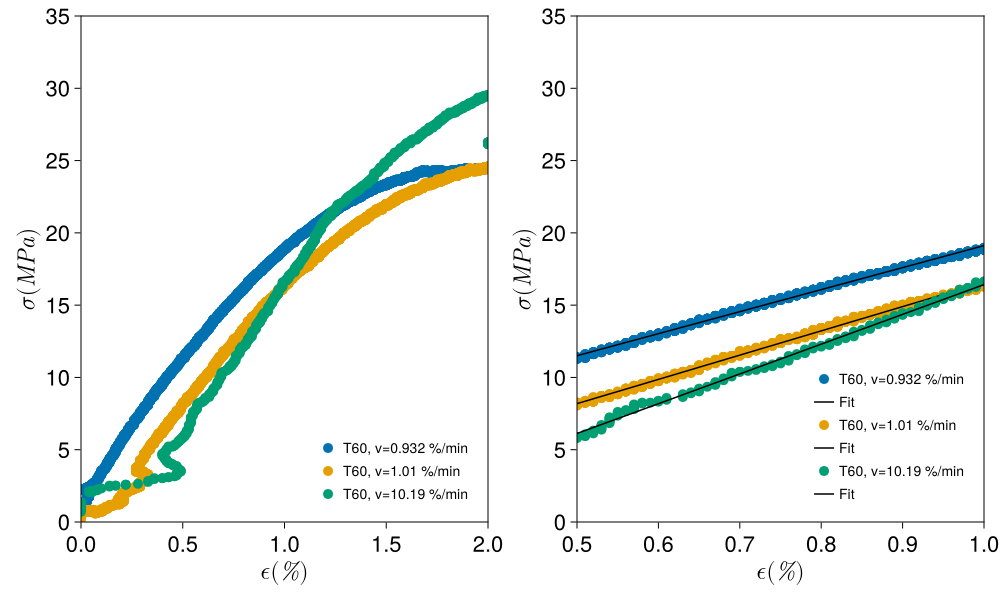

In [39]:
#### Raum T
# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)



for i in [9 10 11]
        
        df=TIRA.computeStressStrain(BaseName,name,i,T,As)
        df=TIRA.filter_range(df,"Zeit",t_range[1],t_range[2])
        df=TIRA.filter_range(df,"dL_ORG",ϵ_range[1],ϵ_range[2])

        properties, df_fit=TIRA.computeProperties(df,ϵ_LinearRange,σ_range)
        
        df_Properties=DataFrame(properties)

        Makie.scatter!(ax1_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")
        
        limits!(ax1_Raum, ϵ_range[1],ϵ_range[2], σ_range[1],σ_range[2])


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")

        Makie.lines!(ax2_Raum ,df_fit[!,:Strain],df_fit[!,:StressFit];
        color = :black, 
        label = "Fit")
        limits!(ax2_Raum, ϵ_LinearRange[1], ϵ_LinearRange[2], σ_range[1],σ_range[2])

        push!(aktuellProperties,properties)
        
end

df_aktuellProperties=DataFrame(aktuellProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)

figRaum

In [40]:
df_aktuellProperties

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,2.65678,50.5051,260126-9,1.98,"[0.5, 1.0]",0.133137,60,1.52304,24.5161,18.9677,0.932089
2,2.46872,50.0,260126-10,2.0,"[0.5, 1.0]",0.128125,60,1.678,24.5806,16.3871,1.00988
3,6.63639,50.0,260126-11,2.0,"[0.5, 1.0]",0.488149,60,2.05936,29.5484,16.6452,10.1898


In [41]:
push!(DataProperties,aktuellProperties[1])
push!(DataProperties,aktuellProperties[2])
push!(DataProperties,aktuellProperties[3])

11-element Vector{Any}:
 Dict{String, Any}("e_max[%]" => 26.527986989324255, "δ_F/δ_B" => 37.17472118959108, "Probe" => "260126-1", "δ_B" => 2.69, "LinearRange [%]" => [0.11, 1.0], "u_E[%] " => 0.43391837312932485, "Temperature [C]" => 22, "E[GPa] " => 3.5792303678701494, "sigmaMax" => 59.677419354838705, "sigma0_25% " => 29.225806451612904…)
 Dict{String, Any}("e_max[%]" => 5.599483284541063, "δ_F/δ_B" => 39.682539682539684, "Probe" => "260126-2", "δ_B" => 2.52, "LinearRange [%]" => [0.1, 1.0], "u_E[%] " => 0.2590609396773203, "Temperature [C]" => 22, "E[GPa] " => 3.4017543510437074, "sigmaMax" => 63.29032258064516, "sigma0_25% " => 37.16129032258065…)
 Dict{String, Any}("e_max[%]" => 4.297253383741574, "δ_F/δ_B" => 51.54639175257732, "Probe" => "260126-3", "δ_B" => 1.94, "LinearRange [%]" => [0.5, 1.0], "u_E[%] " => 0.10892456007959146, "Temperature [C]" => 40, "E[GPa] " => 2.5055038139178634, "sigmaMax" => 33.225806451612904, "sigma0_25% " => 20.516129032258064…)
 Dict{String, Any}(

In [42]:
df_DataProperties=DataFrame(DataProperties)

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,26.528,37.1747,260126-1,2.69,"[0.11, 1.0]",0.433918,22,3.57923,59.6774,29.2258,9.98855
2,5.59948,39.6825,260126-2,2.52,"[0.1, 1.0]",0.259061,22,3.40175,63.2903,37.1613,11.2298
3,4.29725,51.5464,260126-3,1.94,"[0.5, 1.0]",0.108925,40,2.5055,33.2258,20.5161,1.1322
4,2.48575,55.8659,260126-4,1.79,"[0.5, 1.0]",0.174795,40,3.04297,38.129,30.9677,0.883778
5,1.99845,54.9451,260126-5,1.82,"[0.5, 1.0]",0.27083,40,2.71908,43.2903,31.6129,10.9466
6,5.79402,53.4759,260126-6,1.87,"[0.5, 1.0]",0.582814,40,2.7931,42.129,31.5484,10.271
7,4.7615,34.4828,260126-7,2.32,"[0.2, 0.8]",0.0955177,50,2.01977,27.5484,17.6774,1.07343
8,9.09536,31.1284,260126-8,2.57,"[0.2, 0.8]",0.111459,50,1.9333,29.0323,16.6452,1.00756
9,2.65678,50.5051,260126-9,1.98,"[0.5, 1.0]",0.133137,60,1.52304,24.5161,18.9677,0.932089


## Temperatur 80

In [43]:

BaseName="AP5ZMEF01-2/260126-"
name="260126-"
file_path = "$(BaseName)$(2).csv"

"AP5ZMEF01-2/260126-2.csv"

In [44]:
df_260126=[]

Any[]

In [45]:
aktuellProperties=[]

Any[]

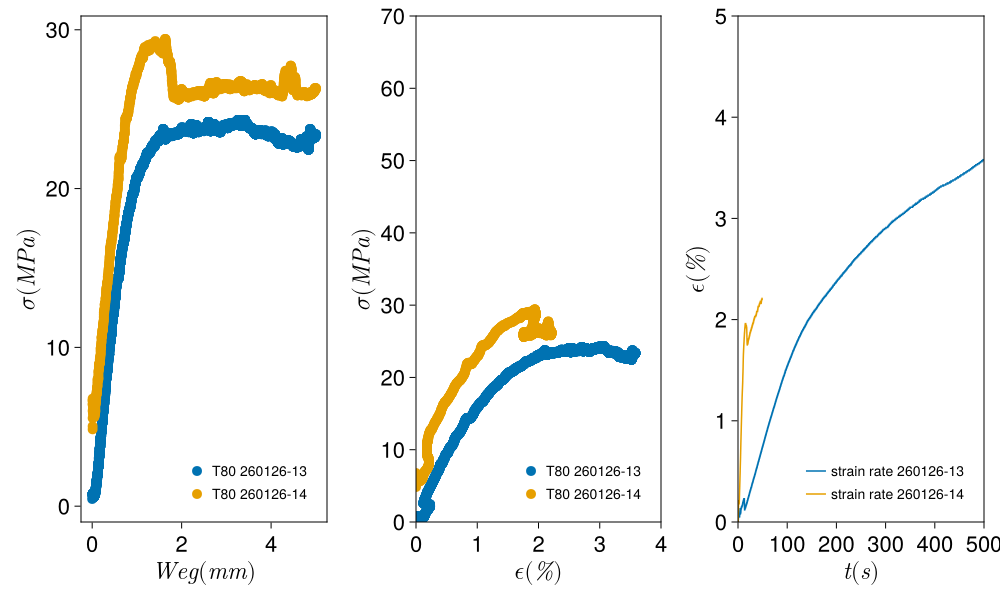

In [47]:

#### T80


# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"Weg (mm)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax3_Raum = Axis(figRaum[1,3],
    xlabel = L"t (s)",
    ylabel = L"ϵ (%)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


## Filter Data


for i in [  13 14]
        
        df=TIRA.computeStressStrain(BaseName,name,i,22,As)
        df=TIRA.filter_range(df,"Weg",0,5)
       

        Makie.scatter!(ax1_Raum ,df[!,:Weg],df[!,:Stress];
        markersize=14, 
        label = "T80 $(name)$(i)")


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T80 $(name)$(i)")
        limits!(ax2_Raum, 0, 4, 0, 70)

    
        Makie.lines!(ax3_Raum ,df[!,:Zeit],df[!,:Strain];
        
        label = "strain rate $(name)$(i)")
        limits!(ax3_Raum, 0, 500, 0, 5)
        #limits!(ax3_Raum, 0.1, 1,0,30)
        
end

df_DataProperties=DataFrame(DataProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax3_Raum, labelsize=font-10, framevisible=false,position = :rb)
figRaum

In [48]:
ϵ_LinearRange=[0.5 1]
ϵ_range=[0 2]
t_range=[0 1000] #in order to avoid wrong measurements from the camera
σ_range=[0 35]
T=80
aktuellProperties=[]

Any[]

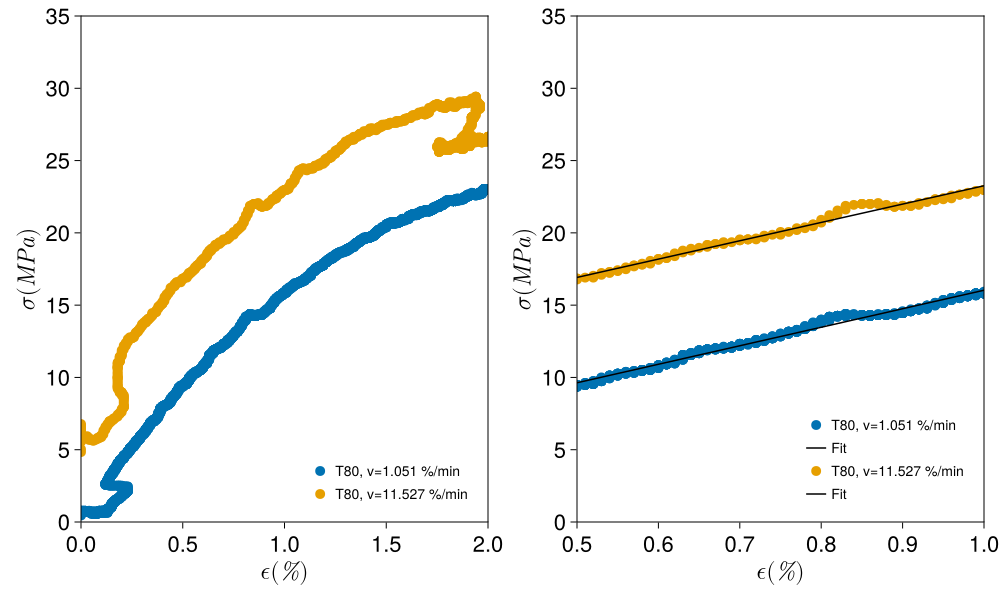

In [49]:
#### Raum T
# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)



for i in [ 13 14]
        
        df=TIRA.computeStressStrain(BaseName,name,i,T,As)
        df=TIRA.filter_range(df,"Zeit",t_range[1],t_range[2])
        df=TIRA.filter_range(df,"dL_ORG",ϵ_range[1],ϵ_range[2])

        properties, df_fit=TIRA.computeProperties(df,ϵ_LinearRange,σ_range)
        
        df_Properties=DataFrame(properties)

        Makie.scatter!(ax1_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")
        
        limits!(ax1_Raum, ϵ_range[1],ϵ_range[2], σ_range[1],σ_range[2])


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")

        Makie.lines!(ax2_Raum ,df_fit[!,:Strain],df_fit[!,:StressFit];
        color = :black, 
        label = "Fit")
        limits!(ax2_Raum, ϵ_LinearRange[1], ϵ_LinearRange[2], σ_range[1],σ_range[2])

        push!(aktuellProperties,properties)
        
end

df_aktuellProperties=DataFrame(aktuellProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)

figRaum

In [50]:
df_aktuellProperties

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,3.53694,50.5051,260126-13,1.98,"[0.5, 1.0]",0.301246,80,1.28044,23.0323,15.9355,1.0511
2,1.62015,51.5464,260126-14,1.94,"[0.5, 1.0]",1.15313,80,1.26804,29.4194,22.9677,11.5265


In [51]:
push!(DataProperties,aktuellProperties[1])
push!(DataProperties,aktuellProperties[2])


13-element Vector{Any}:
 Dict{String, Any}("e_max[%]" => 26.527986989324255, "δ_F/δ_B" => 37.17472118959108, "Probe" => "260126-1", "δ_B" => 2.69, "LinearRange [%]" => [0.11, 1.0], "u_E[%] " => 0.43391837312932485, "Temperature [C]" => 22, "E[GPa] " => 3.5792303678701494, "sigmaMax" => 59.677419354838705, "sigma0_25% " => 29.225806451612904…)
 Dict{String, Any}("e_max[%]" => 5.599483284541063, "δ_F/δ_B" => 39.682539682539684, "Probe" => "260126-2", "δ_B" => 2.52, "LinearRange [%]" => [0.1, 1.0], "u_E[%] " => 0.2590609396773203, "Temperature [C]" => 22, "E[GPa] " => 3.4017543510437074, "sigmaMax" => 63.29032258064516, "sigma0_25% " => 37.16129032258065…)
 Dict{String, Any}("e_max[%]" => 4.297253383741574, "δ_F/δ_B" => 51.54639175257732, "Probe" => "260126-3", "δ_B" => 1.94, "LinearRange [%]" => [0.5, 1.0], "u_E[%] " => 0.10892456007959146, "Temperature [C]" => 40, "E[GPa] " => 2.5055038139178634, "sigmaMax" => 33.225806451612904, "sigma0_25% " => 20.516129032258064…)
 Dict{String, Any}(

In [52]:
df_DataProperties=DataFrame(DataProperties)

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,26.528,37.1747,260126-1,2.69,"[0.11, 1.0]",0.433918,22,3.57923,59.6774,29.2258,9.98855
2,5.59948,39.6825,260126-2,2.52,"[0.1, 1.0]",0.259061,22,3.40175,63.2903,37.1613,11.2298
3,4.29725,51.5464,260126-3,1.94,"[0.5, 1.0]",0.108925,40,2.5055,33.2258,20.5161,1.1322
4,2.48575,55.8659,260126-4,1.79,"[0.5, 1.0]",0.174795,40,3.04297,38.129,30.9677,0.883778
5,1.99845,54.9451,260126-5,1.82,"[0.5, 1.0]",0.27083,40,2.71908,43.2903,31.6129,10.9466
6,5.79402,53.4759,260126-6,1.87,"[0.5, 1.0]",0.582814,40,2.7931,42.129,31.5484,10.271
7,4.7615,34.4828,260126-7,2.32,"[0.2, 0.8]",0.0955177,50,2.01977,27.5484,17.6774,1.07343
8,9.09536,31.1284,260126-8,2.57,"[0.2, 0.8]",0.111459,50,1.9333,29.0323,16.6452,1.00756
9,2.65678,50.5051,260126-9,1.98,"[0.5, 1.0]",0.133137,60,1.52304,24.5161,18.9677,0.932089


## Temperatur 100

In [53]:

BaseName="AP5ZMEF01-2/260126-"
name="260126-"
file_path = "$(BaseName)$(2).csv"

"AP5ZMEF01-2/260126-2.csv"

In [54]:
aktuellProperties=[]

Any[]

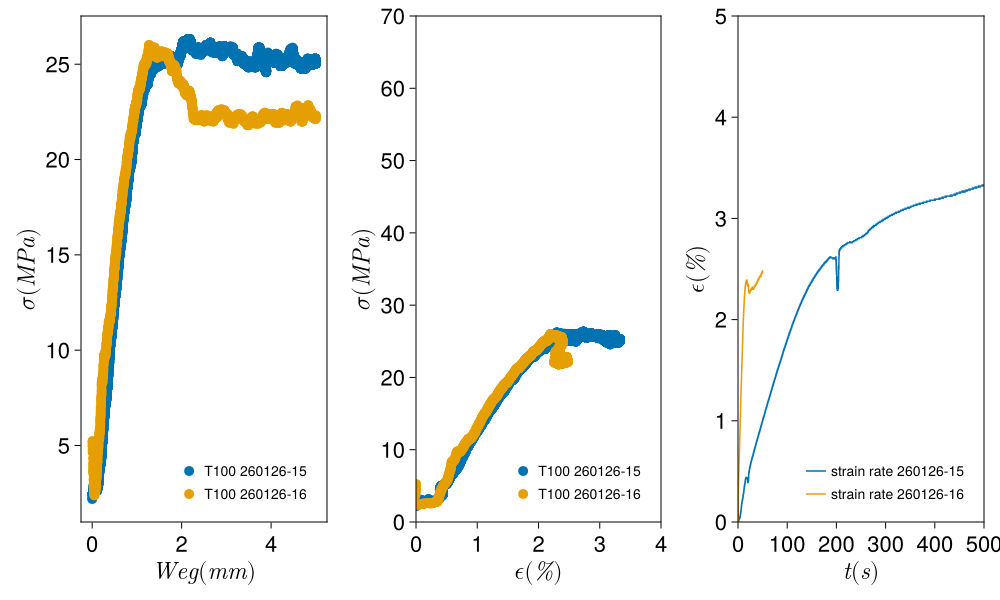

In [55]:

#### T100


# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"Weg (mm)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax3_Raum = Axis(figRaum[1,3],
    xlabel = L"t (s)",
    ylabel = L"ϵ (%)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)


## Filter Data


for i in [  15 16]
        
        df=TIRA.computeStressStrain(BaseName,name,i,22,As)
        df=TIRA.filter_range(df,"Weg",0,5)
       

        Makie.scatter!(ax1_Raum ,df[!,:Weg],df[!,:Stress];
        markersize=14, 
        label = "T100 $(name)$(i)")


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T100 $(name)$(i)")
        limits!(ax2_Raum, 0, 4, 0, 70)

    
        Makie.lines!(ax3_Raum ,df[!,:Zeit],df[!,:Strain];
        
        label = "strain rate $(name)$(i)")
        limits!(ax3_Raum, 0, 500, 0, 5)
        #limits!(ax3_Raum, 0.1, 1,0,30)
        
end

df_DataProperties=DataFrame(DataProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax3_Raum, labelsize=font-10, framevisible=false,position = :rb)
figRaum

In [56]:
ϵ_LinearRange=[0.5 1]
ϵ_range=[0 2]
t_range=[0 1000] #in order to avoid wrong measurements from the camera
σ_range=[0 35]
T=100
aktuellProperties=[]

Any[]

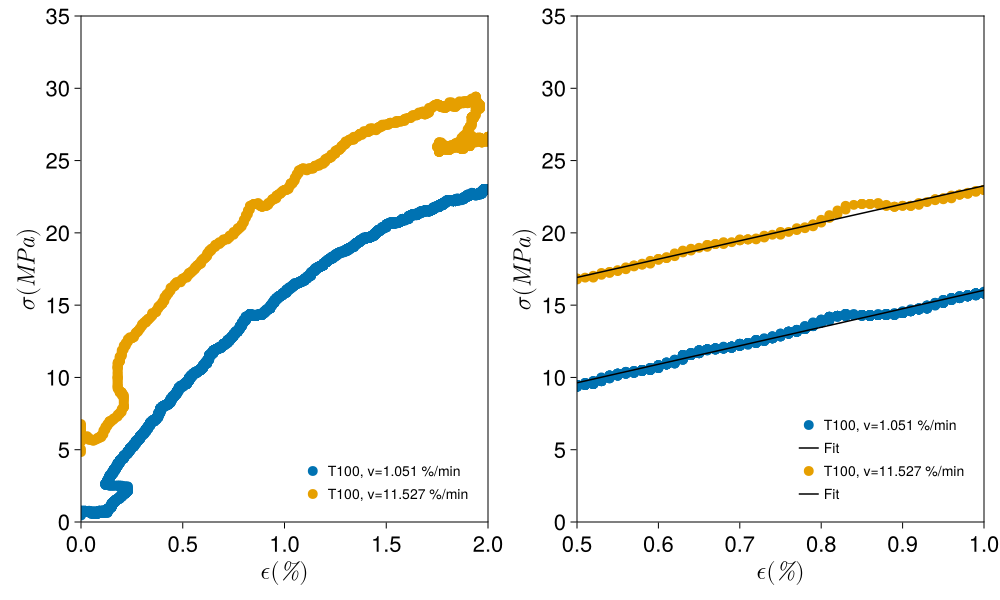

In [57]:
#### Raum T
# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)



for i in [ 13 14]
        
        df=TIRA.computeStressStrain(BaseName,name,i,T,As)
        df=TIRA.filter_range(df,"Zeit",t_range[1],t_range[2])
        df=TIRA.filter_range(df,"dL_ORG",ϵ_range[1],ϵ_range[2])

        properties, df_fit=TIRA.computeProperties(df,ϵ_LinearRange,σ_range)
        
        df_Properties=DataFrame(properties)

        Makie.scatter!(ax1_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")
        
        limits!(ax1_Raum, ϵ_range[1],ϵ_range[2], σ_range[1],σ_range[2])


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T$(T), v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")

        Makie.lines!(ax2_Raum ,df_fit[!,:Strain],df_fit[!,:StressFit];
        color = :black, 
        label = "Fit")
        limits!(ax2_Raum, ϵ_LinearRange[1], ϵ_LinearRange[2], σ_range[1],σ_range[2])

        push!(aktuellProperties,properties)
        
end

df_aktuellProperties=DataFrame(aktuellProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)

figRaum

In [58]:
df_aktuellProperties

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,3.53694,50.5051,260126-13,1.98,"[0.5, 1.0]",0.301246,100,1.28044,23.0323,15.9355,1.0511
2,1.62015,51.5464,260126-14,1.94,"[0.5, 1.0]",1.15313,100,1.26804,29.4194,22.9677,11.5265


In [59]:
push!(DataProperties,aktuellProperties[1])
push!(DataProperties,aktuellProperties[2])


15-element Vector{Any}:
 Dict{String, Any}("e_max[%]" => 26.527986989324255, "δ_F/δ_B" => 37.17472118959108, "Probe" => "260126-1", "δ_B" => 2.69, "LinearRange [%]" => [0.11, 1.0], "u_E[%] " => 0.43391837312932485, "Temperature [C]" => 22, "E[GPa] " => 3.5792303678701494, "sigmaMax" => 59.677419354838705, "sigma0_25% " => 29.225806451612904…)
 Dict{String, Any}("e_max[%]" => 5.599483284541063, "δ_F/δ_B" => 39.682539682539684, "Probe" => "260126-2", "δ_B" => 2.52, "LinearRange [%]" => [0.1, 1.0], "u_E[%] " => 0.2590609396773203, "Temperature [C]" => 22, "E[GPa] " => 3.4017543510437074, "sigmaMax" => 63.29032258064516, "sigma0_25% " => 37.16129032258065…)
 Dict{String, Any}("e_max[%]" => 4.297253383741574, "δ_F/δ_B" => 51.54639175257732, "Probe" => "260126-3", "δ_B" => 1.94, "LinearRange [%]" => [0.5, 1.0], "u_E[%] " => 0.10892456007959146, "Temperature [C]" => 40, "E[GPa] " => 2.5055038139178634, "sigmaMax" => 33.225806451612904, "sigma0_25% " => 20.516129032258064…)
 Dict{String, Any}(

In [60]:
df_DataProperties=DataFrame(DataProperties)

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,26.528,37.1747,260126-1,2.69,"[0.11, 1.0]",0.433918,22,3.57923,59.6774,29.2258,9.98855
2,5.59948,39.6825,260126-2,2.52,"[0.1, 1.0]",0.259061,22,3.40175,63.2903,37.1613,11.2298
3,4.29725,51.5464,260126-3,1.94,"[0.5, 1.0]",0.108925,40,2.5055,33.2258,20.5161,1.1322
4,2.48575,55.8659,260126-4,1.79,"[0.5, 1.0]",0.174795,40,3.04297,38.129,30.9677,0.883778
5,1.99845,54.9451,260126-5,1.82,"[0.5, 1.0]",0.27083,40,2.71908,43.2903,31.6129,10.9466
6,5.79402,53.4759,260126-6,1.87,"[0.5, 1.0]",0.582814,40,2.7931,42.129,31.5484,10.271
7,4.7615,34.4828,260126-7,2.32,"[0.2, 0.8]",0.0955177,50,2.01977,27.5484,17.6774,1.07343
8,9.09536,31.1284,260126-8,2.57,"[0.2, 0.8]",0.111459,50,1.9333,29.0323,16.6452,1.00756
9,2.65678,50.5051,260126-9,1.98,"[0.5, 1.0]",0.133137,60,1.52304,24.5161,18.9677,0.932089
